In [16]:
# ============================================================
# KÜTÜPHANELER
# ============================================================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

os.makedirs("figures", exist_ok=True)

In [17]:
# ============================================================
# GÜNEŞ VERİSİ — Open-Meteo Historical API
# ============================================================

coords = {
    "UK":      {"latitude": 51.51, "longitude": -0.13},   # London
    "Germany": {"latitude": 52.52, "longitude": 13.40},   # Berlin
    "Spain":   {"latitude": 40.42, "longitude": -3.70},   # Madrid
    "Turkey":  {"latitude": 39.93, "longitude": 32.85}    # Ankara
}

all_dfs = []

for country, loc in coords.items():
    print(f"{country} çekiliyor...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": loc["latitude"],
        "longitude": loc["longitude"],
        "start_date": "2015-01-01",
        "end_date": "2024-12-31",
        "hourly": "sunshine_duration",
        "timezone": "UTC"
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame({
        "time": data["hourly"]["time"],
        "sunshine_duration_seconds": data["hourly"]["sunshine_duration"]
    })
    df["time"] = pd.to_datetime(df["time"])
    df["country"] = country
    df["sunshine_hours"] = df["sunshine_duration_seconds"] / 3600.0

    monthly = (
        df.groupby([pd.Grouper(key="time", freq="MS"), "country"], as_index=False)
        .agg(
            monthly_total_sunshine_hours=("sunshine_hours", "sum"),
            avg_daily_sunshine_hours=("sunshine_hours", "mean")
        )
    )
    monthly["days_in_month"] = monthly["time"].dt.days_in_month
    monthly["TIME_PERIOD"] = monthly["time"].dt.strftime("%Y-%m")
    all_dfs.append(monthly)
    print(f"✅ {country} tamam")

sun_df = pd.concat(all_dfs, ignore_index=True)
sun_df = sun_df.rename(columns={"monthly_total_sunshine_hours": "sunshine_hours"})
sun_df["year_month"] = pd.to_datetime(sun_df["TIME_PERIOD"]).dt.to_period("M")
sun_df = sun_df[["country", "year_month", "sunshine_hours"]]

print(f"\n✅ Güneş verisi: {sun_df.shape}")
print(sun_df.groupby("country").size())

UK çekiliyor...
✅ UK tamam
Germany çekiliyor...
✅ Germany tamam
Spain çekiliyor...
✅ Spain tamam
Turkey çekiliyor...
✅ Turkey tamam

✅ Güneş verisi: (480, 3)
country
Germany    120
Spain      120
Turkey     120
UK         120
dtype: int64


In [21]:
# ============================================================
# CCI VERİSİ — OECD
# Dosyayı Colab'a yükledikten sonra çalıştır
# ============================================================

cci_raw = pd.read_csv("/content/oecd_cci_monthly.csv.csv")

countries_map = {
    "United Kingdom": "UK",
    "Germany":        "Germany",
    "Spain":          "Spain",
    "Türkiye":        "Turkey"
}

cci = cci_raw[cci_raw["Reference area"].isin(countries_map.keys())][
    ["Reference area", "TIME_PERIOD", "OBS_VALUE"]
].copy()

cci["country"] = cci["Reference area"].map(countries_map)
cci["year_month"] = pd.to_datetime(cci["TIME_PERIOD"]).dt.to_period("M")
cci["CCI"] = pd.to_numeric(cci["OBS_VALUE"], errors="coerce")
cci = cci[["country", "year_month", "CCI"]].dropna()
cci = cci[(cci["year_month"] >= "2015-01") & (cci["year_month"] <= "2024-12")]

print(f"✅ CCI verisi: {cci.shape}")
print(cci.groupby("country").size())

✅ CCI verisi: (480, 3)
country
Germany    120
Spain      120
Turkey     120
UK         120
dtype: int64


In [22]:
# ============================================================
# MERGE
# ============================================================

sun_df["year_month"] = pd.to_datetime(
    sun_df["year_month"].astype(str)).dt.to_period("M")
cci["year_month"] = pd.to_datetime(
    cci["year_month"].astype(str)).dt.to_period("M")

df_full = pd.merge(cci, sun_df, on=["country", "year_month"])

print(f"✅ Merged: {df_full.shape}")
print(df_full.groupby("country").size())
print(df_full.head())

✅ Merged: (480, 4)
country
Germany    120
Spain      120
Turkey     120
UK         120
dtype: int64
   country year_month        CCI  sunshine_hours
0  Germany    2022-08   99.58981      335.601022
1  Germany    2022-07   99.87942      395.979239
2  Germany    2022-06  100.21250      410.117092
3  Germany    2022-05  100.54920      383.985578
4  Germany    2022-04  100.88260      266.233800


Eksik değer sayısı:
country           0
year_month        0
CCI               0
sunshine_hours    0
dtype: int64


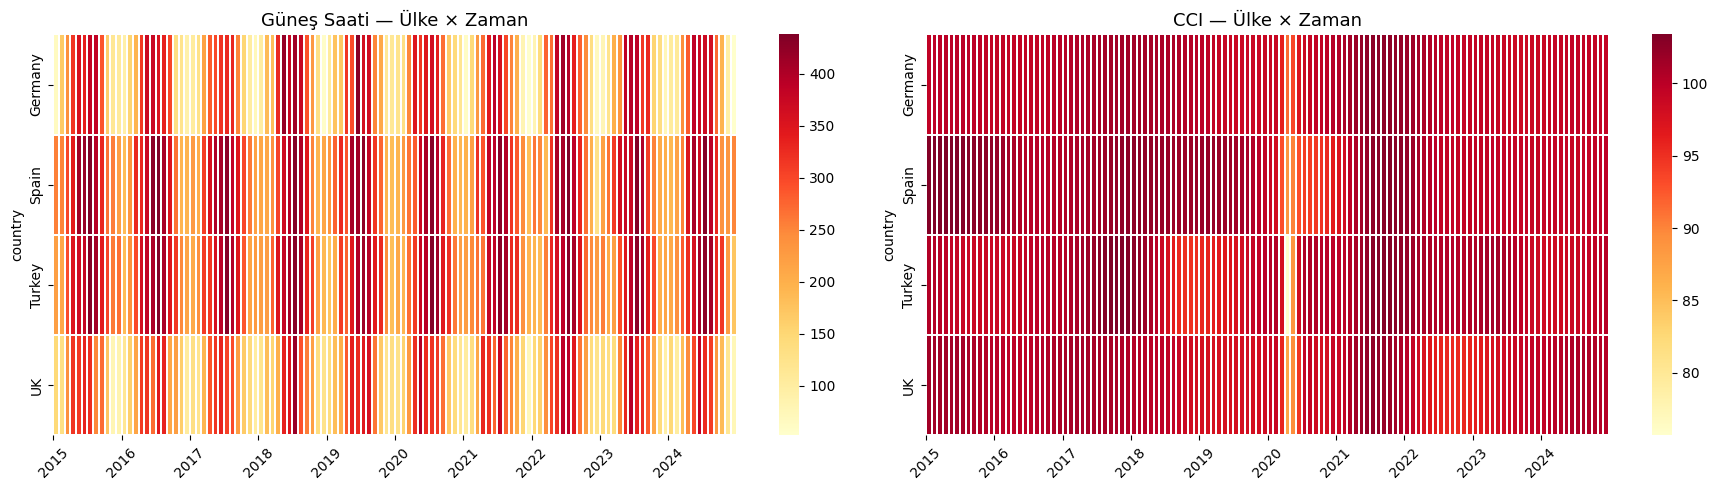

✅ Heatmap kaydedildi


In [23]:
# ============================================================
# EDA 1 — EKSİK VERİ KONTROLÜ + HEATMAP
# ============================================================

print("Eksik değer sayısı:")
print(df_full.isnull().sum())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, (col, title) in enumerate([
    ("sunshine_hours", "Güneş Saati"),
    ("CCI", "CCI")
]):
    pivot = df_full.pivot_table(
        index="country", columns="year_month", values=col)
    sns.heatmap(pivot, ax=axes[idx], cmap="YlOrRd",
                cbar=True, linewidths=0.1)
    axes[idx].set_title(f"{title} — Ülke × Zaman", fontsize=13)
    axes[idx].set_xlabel("")
    ticks = [i for i, c in enumerate(pivot.columns)
             if str(c).endswith("01")]
    axes[idx].set_xticks(ticks)
    axes[idx].set_xticklabels(
        [str(pivot.columns[i])[:4] for i in ticks], rotation=45)

plt.tight_layout()
plt.savefig("figures/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap kaydedildi")

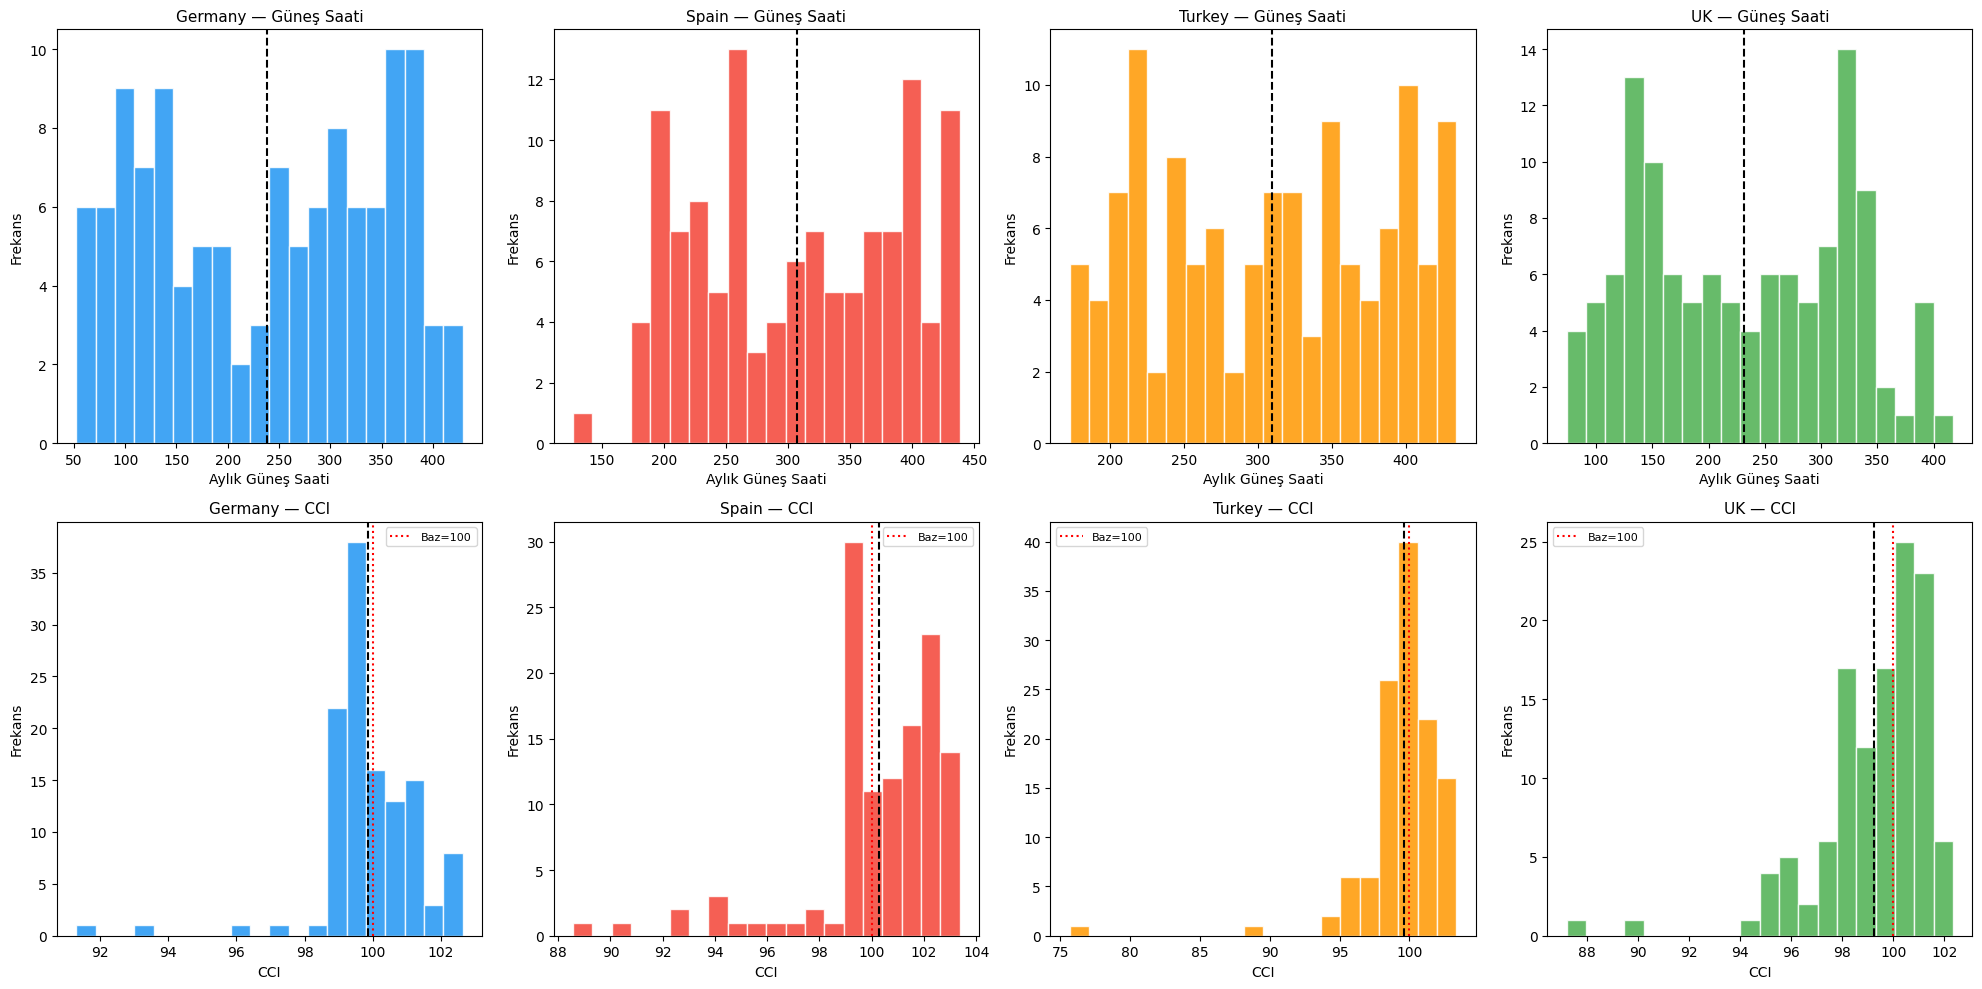

✅ Dağılım grafikleri kaydedildi


In [24]:
# ============================================================
# EDA 2 — DAĞILIM GRAFİKLERİ
# ============================================================

countries = ["Germany", "Spain", "Turkey", "UK"]
colors = {"Germany": "#2196F3", "Spain": "#F44336",
          "Turkey": "#FF9800", "UK": "#4CAF50"}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, country in enumerate(countries):
    subset = df_full[df_full["country"] == country]
    color = colors[country]

    # Güneş histogram
    axes[0, i].hist(subset["sunshine_hours"], bins=20,
                    color=color, edgecolor="white", alpha=0.85)
    axes[0, i].axvline(subset["sunshine_hours"].mean(),
                       color="black", linestyle="--", linewidth=1.5)
    axes[0, i].set_title(f"{country} — Güneş Saati", fontsize=11)
    axes[0, i].set_xlabel("Aylık Güneş Saati")
    axes[0, i].set_ylabel("Frekans")

    # CCI histogram
    axes[1, i].hist(subset["CCI"], bins=20,
                    color=color, edgecolor="white", alpha=0.85)
    axes[1, i].axvline(subset["CCI"].mean(),
                       color="black", linestyle="--", linewidth=1.5)
    axes[1, i].axvline(100, color="red", linestyle=":",
                       linewidth=1.5, label="Baz=100")
    axes[1, i].set_title(f"{country} — CCI", fontsize=11)
    axes[1, i].set_xlabel("CCI")
    axes[1, i].set_ylabel("Frekans")
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dağılım grafikleri kaydedildi")

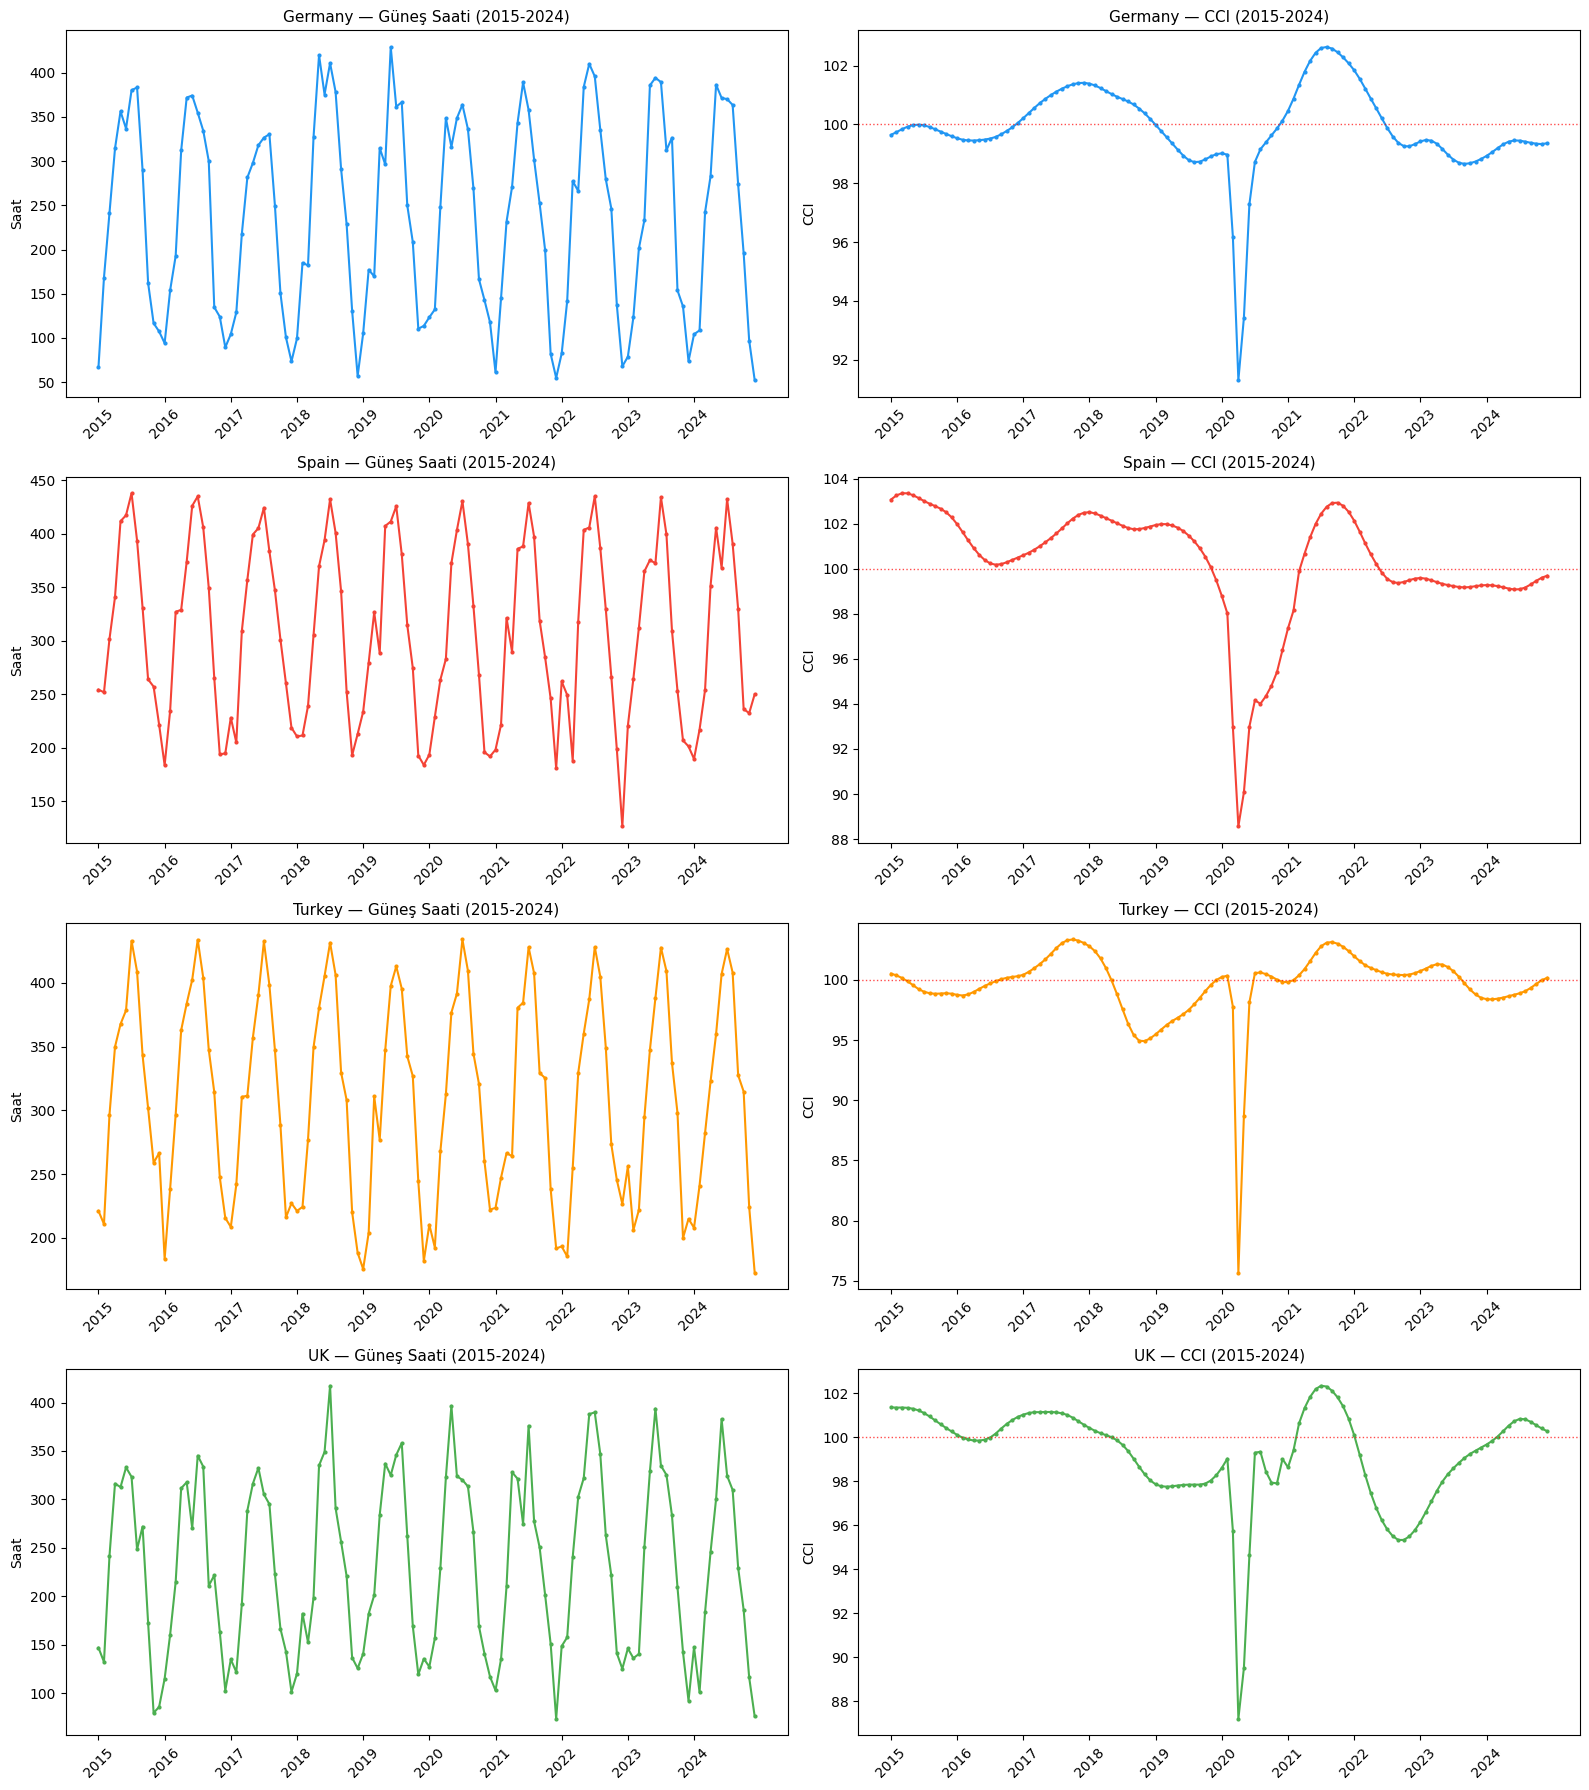

✅ Zaman serisi kaydedildi


In [25]:
# ============================================================
# EDA 3 — ZAMAN SERİSİ GRAFİKLERİ
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(16, 18))

for i, country in enumerate(countries):
    subset = df_full[df_full["country"] == country].sort_values("year_month")
    color = colors[country]
    x = range(len(subset))

    # Güneş
    axes[i, 0].plot(x, subset["sunshine_hours"],
                    color=color, linewidth=1.5, marker="o", markersize=2)
    axes[i, 0].set_title(f"{country} — Güneş Saati (2015-2024)", fontsize=11)
    axes[i, 0].set_ylabel("Saat")
    ticks = list(range(0, 120, 12))
    axes[i, 0].set_xticks(ticks)
    axes[i, 0].set_xticklabels([str(2015+j) for j in range(10)], rotation=45)

    # CCI
    axes[i, 1].plot(x, subset["CCI"],
                    color=color, linewidth=1.5, marker="o", markersize=2)
    axes[i, 1].axhline(100, color="red", linestyle=":", linewidth=1, alpha=0.7)
    axes[i, 1].set_title(f"{country} — CCI (2015-2024)", fontsize=11)
    axes[i, 1].set_ylabel("CCI")
    axes[i, 1].set_xticks(ticks)
    axes[i, 1].set_xticklabels([str(2015+j) for j in range(10)], rotation=45)

plt.tight_layout()
plt.savefig("figures/time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Zaman serisi kaydedildi")

PEARSON KORELASYONu
Germany   : r=-0.099, p=0.284 → ❌ Anlamlı değil
Spain     : r=+0.016, p=0.864 → ❌ Anlamlı değil
Turkey    : r=-0.019, p=0.835 → ❌ Anlamlı değil
UK        : r=-0.137, p=0.134 → ❌ Anlamlı değil

SPEARMAN KORELASYONu
Germany   : r=-0.070, p=0.447 → ❌ Anlamlı değil
Spain     : r=+0.042, p=0.649 → ❌ Anlamlı değil
Turkey    : r=-0.026, p=0.778 → ❌ Anlamlı değil
UK        : r=-0.048, p=0.601 → ❌ Anlamlı değil


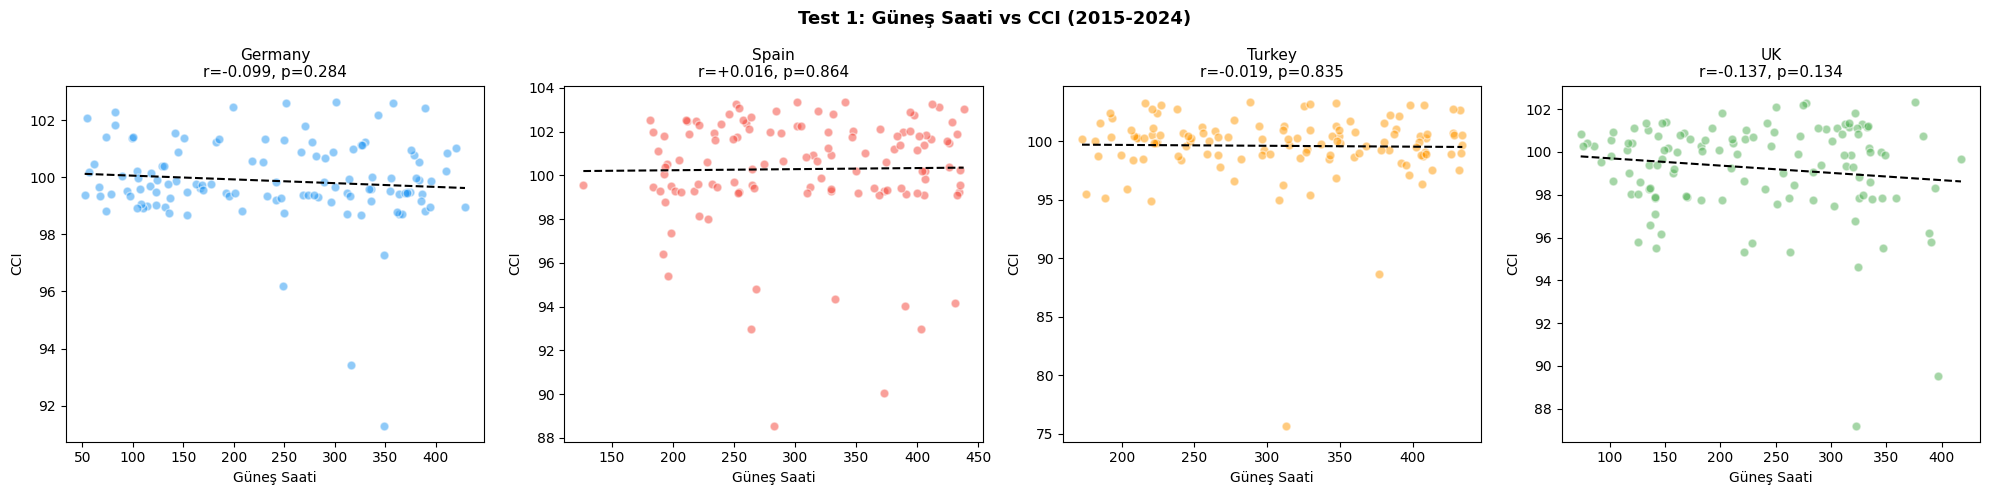

✅ Test 1 kaydedildi


In [26]:
# ============================================================
# TEST 1 — PEARSON & SPEARMAN KORELASYONu
# H0: Güneş saati ile CCI arasında ilişki yoktur
# ============================================================

print("=" * 55)
print("PEARSON KORELASYONu")
print("=" * 55)
pearson_results = {}
for country in countries:
    subset = df_full[df_full["country"] == country]
    r, p = stats.pearsonr(subset["sunshine_hours"], subset["CCI"])
    pearson_results[country] = {"r": r, "p": p}
    sig = "✅ Anlamlı" if p < 0.05 else "❌ Anlamlı değil"
    print(f"{country:10s}: r={r:+.3f}, p={p:.3f} → {sig}")

print("\n" + "=" * 55)
print("SPEARMAN KORELASYONu")
print("=" * 55)
spearman_results = {}
for country in countries:
    subset = df_full[df_full["country"] == country]
    r, p = stats.spearmanr(subset["sunshine_hours"], subset["CCI"])
    spearman_results[country] = {"r": r, "p": p}
    sig = "✅ Anlamlı" if p < 0.05 else "❌ Anlamlı değil"
    print(f"{country:10s}: r={r:+.3f}, p={p:.3f} → {sig}")

# Scatter plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, country in enumerate(countries):
    subset = df_full[df_full["country"] == country]
    color = colors[country]
    axes[i].scatter(subset["sunshine_hours"], subset["CCI"],
                    alpha=0.5, color=color, edgecolors="white", s=40)
    z = np.polyfit(subset["sunshine_hours"], subset["CCI"], 1)
    x_line = np.linspace(subset["sunshine_hours"].min(),
                         subset["sunshine_hours"].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), "k--", linewidth=1.5)
    pr = pearson_results[country]["r"]
    pp = pearson_results[country]["p"]
    axes[i].set_title(f"{country}\nr={pr:+.3f}, p={pp:.3f}", fontsize=11)
    axes[i].set_xlabel("Güneş Saati")
    axes[i].set_ylabel("CCI")

plt.suptitle("Test 1: Güneş Saati vs CCI (2015-2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/test1_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Test 1 kaydedildi")

LAG ANALİZİ — Geçen Ay Güneş vs Bu Ay CCI
Germany   : r=-0.072, p=0.434 → ❌ Anlamlı değil
Spain     : r=+0.045, p=0.628 → ❌ Anlamlı değil
Turkey    : r=+0.050, p=0.588 → ❌ Anlamlı değil
UK        : r=-0.076, p=0.410 → ❌ Anlamlı değil


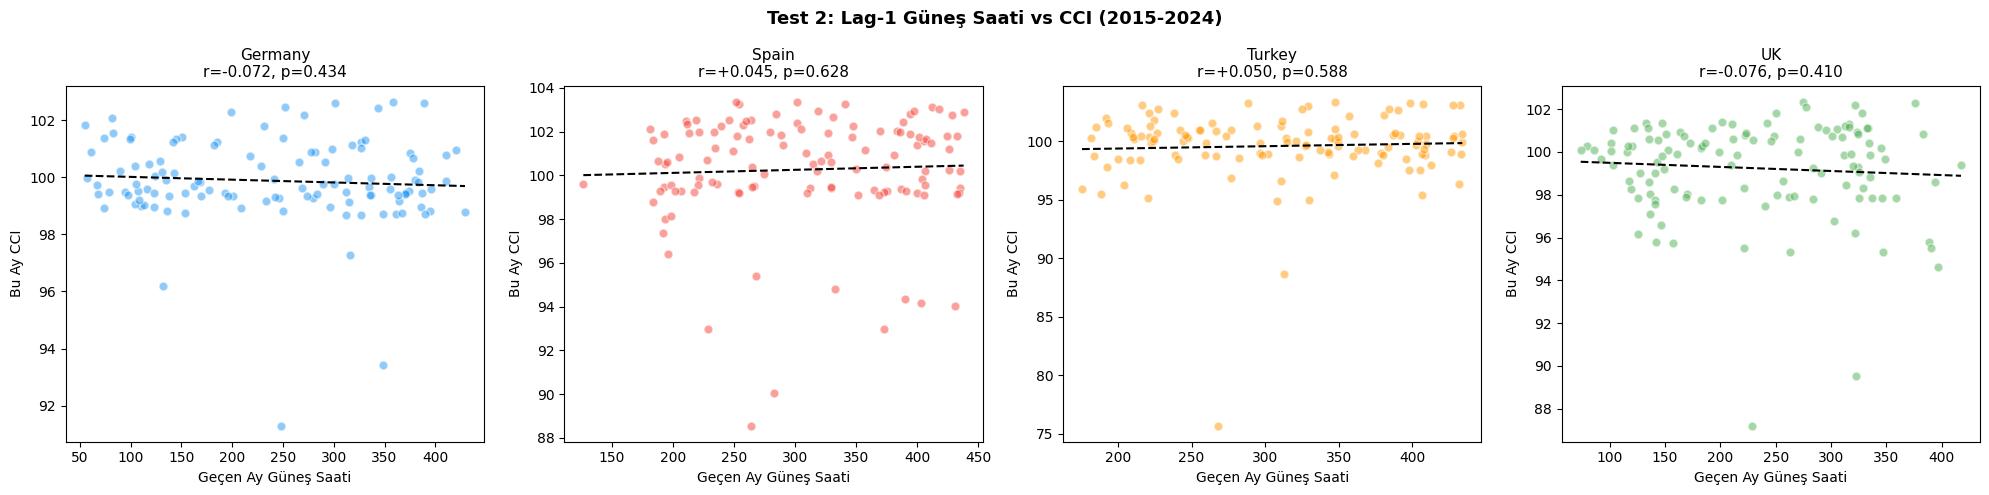

✅ Test 2 kaydedildi


In [28]:
# ============================================================
# TEST 2 — LAG ANALİZİ
# H0: Geçen ayın güneşi bu ayın CCI'ını etkilemez
# ============================================================

print("=" * 55)
print("LAG ANALİZİ — Geçen Ay Güneş vs Bu Ay CCI")
print("=" * 55)

lag_results = {}
for country in countries:
    subset = df_full[df_full["country"] == country].sort_values("year_month").copy()
    subset["sunshine_lag1"] = subset["sunshine_hours"].shift(1)
    subset = subset.dropna()
    r, p = stats.pearsonr(subset["sunshine_lag1"], subset["CCI"])
    lag_results[country] = {"r": r, "p": p}
    sig = "✅ Anlamlı" if p < 0.05 else "❌ Anlamlı değil"
    print(f"{country:10s}: r={r:+.3f}, p={p:.3f} → {sig}")

# Scatter
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, country in enumerate(countries):
    subset = df_full[df_full["country"] == country].sort_values("year_month").copy()
    subset["sunshine_lag1"] = subset["sunshine_hours"].shift(1)
    subset = subset.dropna()
    color = colors[country]
    axes[i].scatter(subset["sunshine_lag1"], subset["CCI"],
                    alpha=0.5, color=color, edgecolors="white", s=40)
    z = np.polyfit(subset["sunshine_lag1"], subset["CCI"], 1)
    x_line = np.linspace(subset["sunshine_lag1"].min(),
                         subset["sunshine_lag1"].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), "k--", linewidth=1.5)
    r = lag_results[country]["r"]
    p = lag_results[country]["p"]
    axes[i].set_title(f"{country}\nr={r:+.3f}, p={p:.3f}", fontsize=11)
    axes[i].set_xlabel("Geçen Ay Güneş Saati")
    axes[i].set_ylabel("Bu Ay CCI")

plt.suptitle("Test 2: Lag-1 Güneş Saati vs CCI (2015-2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/test2_lag.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Test 2 kaydedildi")

MEVSİMSEL T-TEST — Yaz vs Kış CCI
Germany   : t=-0.339, p=0.736 → ❌ Anlamlı değil
           Yaz ort=99.94, Kış ort=100.04
Spain     : t=-0.646, p=0.521 → ❌ Anlamlı değil
           Yaz ort=100.23, Kış ort=100.61
Turkey    : t=+0.005, p=0.996 → ❌ Anlamlı değil
           Yaz ort=99.90, Kış ort=99.90
UK        : t=+0.209, p=0.836 → ❌ Anlamlı değil
           Yaz ort=99.50, Kış ort=99.40


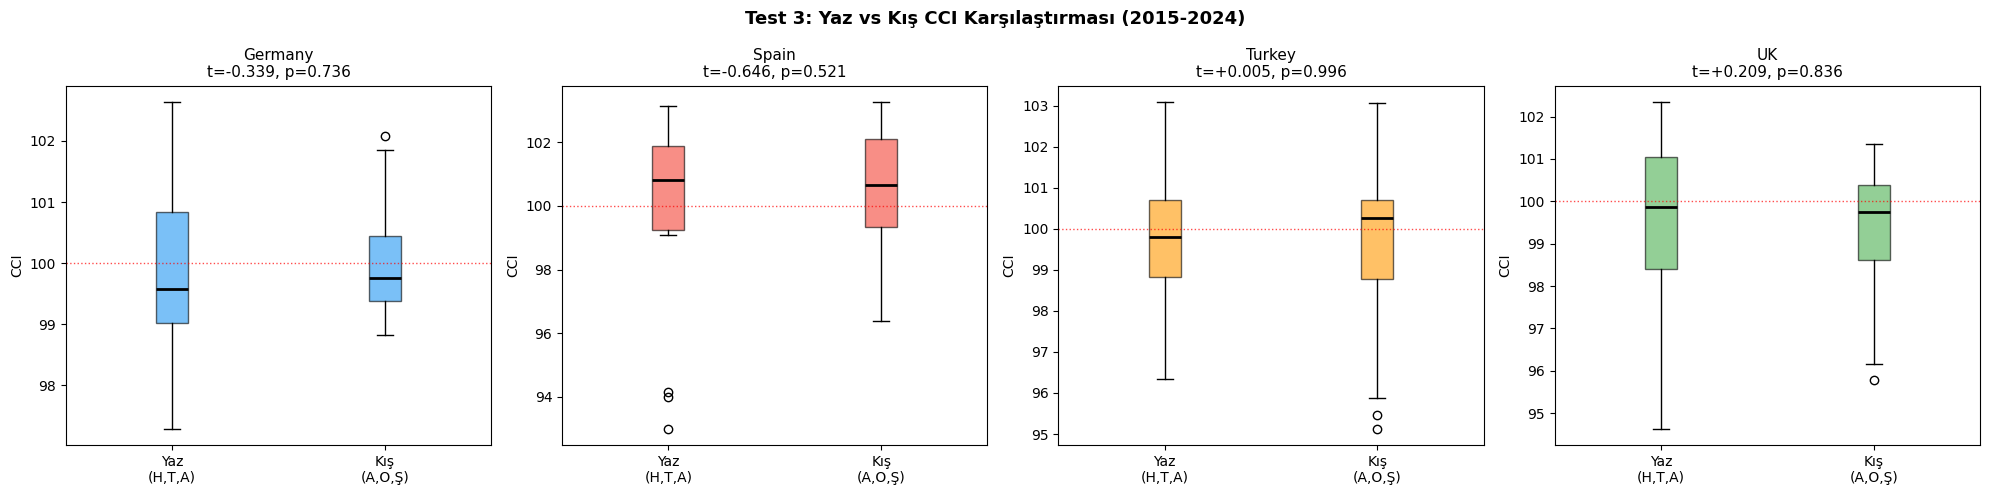

✅ Test 3 kaydedildi


In [29]:
# ============================================================
# TEST 3 — MEVSİMSEL T-TEST
# H0: Yaz ve kış aylarında CCI arasında fark yoktur
# ============================================================

print("=" * 55)
print("MEVSİMSEL T-TEST — Yaz vs Kış CCI")
print("=" * 55)

# Yaz: Haziran, Temmuz, Ağustos (6,7,8)
# Kış: Aralık, Ocak, Şubat (12,1,2)

df_full["month"] = df_full["year_month"].dt.month

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, country in enumerate(countries):
    subset = df_full[df_full["country"] == country]
    summer = subset[subset["month"].isin([6, 7, 8])]["CCI"]
    winter = subset[subset["month"].isin([12, 1, 2])]["CCI"]
    t, p = stats.ttest_ind(summer, winter)
    sig = "✅ Anlamlı" if p < 0.05 else "❌ Anlamlı değil"
    print(f"{country:10s}: t={t:+.3f}, p={p:.3f} → {sig}")
    print(f"           Yaz ort={summer.mean():.2f}, Kış ort={winter.mean():.2f}")

    # Boxplot
    color = colors[country]
    axes[i].boxplot([summer, winter],
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color="black", linewidth=2))
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(["Yaz\n(H,T,A)", "Kış\n(A,O,Ş)"])
    axes[i].set_title(f"{country}\nt={t:+.3f}, p={p:.3f}", fontsize=11)
    axes[i].set_ylabel("CCI")
    axes[i].axhline(100, color="red", linestyle=":", linewidth=1, alpha=0.7)

plt.suptitle("Test 3: Yaz vs Kış CCI Karşılaştırması (2015-2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/test3_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Test 3 kaydedildi")

DEĞİŞKENLİK KARŞILAŞTIRMASI
country  sunshine_std  cci_std
Germany    111.554459 1.487568
  Spain     82.480530 2.591261
 Turkey     78.387726 3.068609
     UK     91.068402 2.258920

Değişkenlik korelasyonu: r=-0.979, p=0.021 → ✅ Anlamlı
Not: 4 ülke olduğu için istatistiksel güç düşüktür.


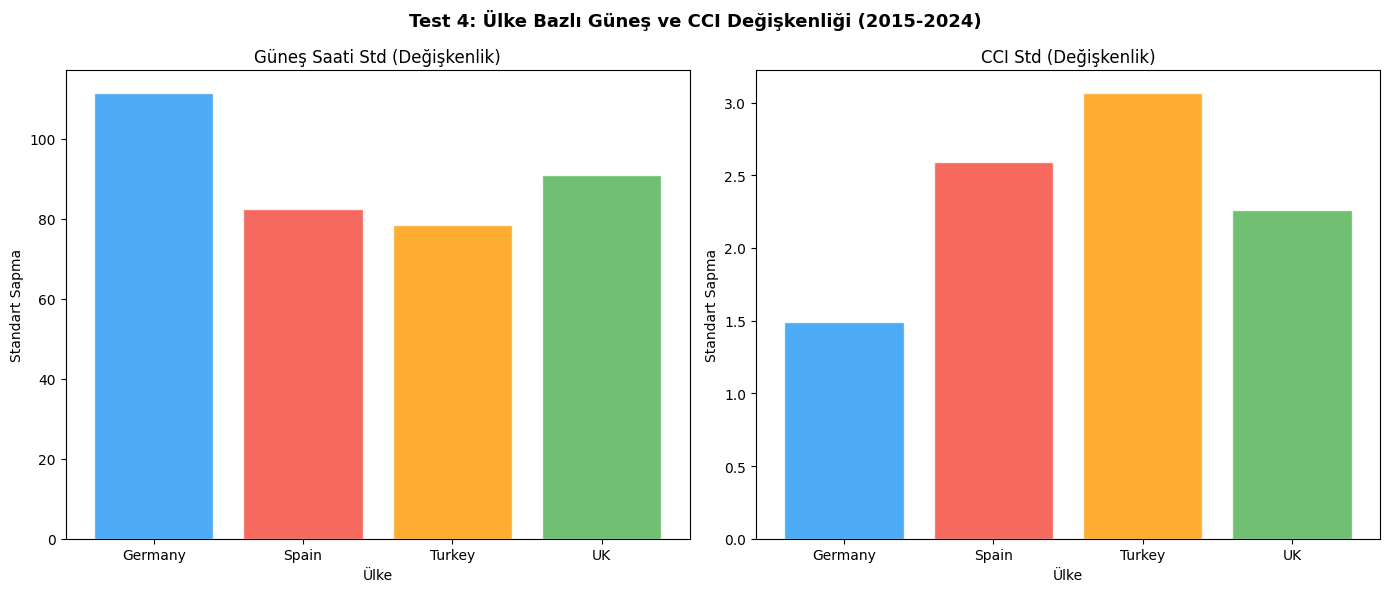

✅ Test 4 kaydedildi


In [30]:
# ============================================================
# TEST 4 — ÜLKE BAZLI DEĞİŞKENLİK KARŞILAŞTIRMASI
# H0: Güneş değişkenliği ile CCI değişkenliği arasında ilişki yoktur
# ============================================================

print("=" * 55)
print("DEĞİŞKENLİK KARŞILAŞTIRMASI")
print("=" * 55)

variability = df_full.groupby("country").agg(
    sunshine_std=("sunshine_hours", "std"),
    cci_std=("CCI", "std")
).reset_index()

print(variability.to_string(index=False))

r, p = stats.pearsonr(variability["sunshine_std"], variability["cci_std"])
sig = "✅ Anlamlı" if p < 0.05 else "❌ Anlamlı değil"
print(f"\nDeğişkenlik korelasyonu: r={r:+.3f}, p={p:.3f} → {sig}")
print("Not: 4 ülke olduğu için istatistiksel güç düşüktür.")

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: Güneş değişkenliği
axes[0].bar(variability["country"], variability["sunshine_std"],
            color=[colors[c] for c in variability["country"]], alpha=0.8,
            edgecolor="white")
axes[0].set_title("Güneş Saati Std (Değişkenlik)", fontsize=12)
axes[0].set_ylabel("Standart Sapma")
axes[0].set_xlabel("Ülke")

# Sağ: CCI değişkenliği
axes[1].bar(variability["country"], variability["cci_std"],
            color=[colors[c] for c in variability["country"]], alpha=0.8,
            edgecolor="white")
axes[1].set_title("CCI Std (Değişkenlik)", fontsize=12)
axes[1].set_ylabel("Standart Sapma")
axes[1].set_xlabel("Ülke")

plt.suptitle("Test 4: Ülke Bazlı Güneş ve CCI Değişkenliği (2015-2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/test4_variability.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Test 4 kaydedildi")

In [27]:
import shutil
from google.colab import files

shutil.make_archive("figures", "zip", "figures")
files.download("figures.zip")
print("✅ figures.zip indirildi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ figures.zip indirildi
